In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

Accuracy: 0.8045

Bảng phân loại:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



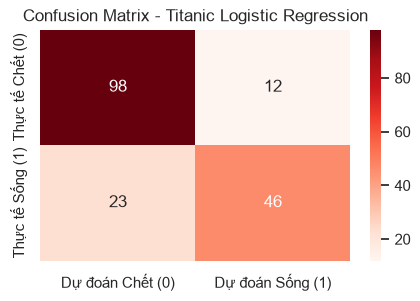

In [4]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

full_pipeline = Pipeline([
    ("preprocessing", preprocess),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

X = df.drop(columns=["survived"])
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nBảng phân loại:")
print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Dự đoán Chết (0)', 'Dự đoán Sống (1)'],
            yticklabels=['Thực tế Chết (0)', 'Thực tế Sống (1)'])
plt.title('Confusion Matrix - Titanic Logistic Regression')
plt.show()

**Đánh giá Logistic Regression**

- Accuracy: 80.45% 
- Precision: 
    + Lớp 0: 0.81
    + Lớp 1: 0.79
- Recall: 
    + Lớp 0: 0.89
    + Lớp 1: 0.67
- F1-score: 0.85 cho lớp 0 (chết) và 0.72 cho lớp 1 (sống)

Nhận xét: mô hình làm tốt trong việc nhận diện người chết. Tuy nhiên nó gặp khó khăn trong việc đoán những người sống sót.


**So sánh Logistic Regression và Linear Regression**

- Bản chất linear regression dùng để dự đoán giá trị liên tục. Khi áp dụng vào bài toán phân loại nhãn như bài toán này, đường thẳng hồi quy có thể trả về các giá trị không mang giá trị xác suất (ngoài vùng [0,1])
- Do đó Logistic Regression sẽ phù hợp hơn với bài này. Bên cạnh đó là nó không bị nhiễu nặng bởi các điểm dữ liệu kì dị như linear

